# Navigation

---

Congratulations for completing the first project of the [Deep Reinforcement Learning Nanodegree](https://www.udacity.com/course/deep-reinforcement-learning-nanodegree--nd893)!  In this notebook, you will learn how to control an agent in a more challenging environment, where it can learn directly from raw pixels!  **Note that this exercise is optional!**

### 1. Start the Environment

We begin by importing some necessary packages.  If the code cell below returns an error, please revisit the project instructions to double-check that you have installed [Unity ML-Agents](https://github.com/Unity-Technologies/ml-agents/blob/master/docs/Installation.md) and [NumPy](http://www.numpy.org/).

In [1]:
import torch
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
%matplotlib inline

# Den alten Typen temporar auf die neuen Aliase umleiten
if not hasattr(np, 'float_'):
    np.float_ = np.float64
if not hasattr(np, 'int_'):
    np.int_ = np.int64

# Jetzt erst die Umgebung importieren
from unityagents import UnityEnvironment
from dqn_agent import Agent
from model import QNetwork, DuelingQNetwork, DQNNatureNetwork, DuelingDQNNatureNetwork

Next, we will start the environment!  **_Before running the code cell below_**, change the `file_name` parameter to match the location of the Unity environment that you downloaded.

- **Mac**: `"path/to/VisualBanana.app"`
- **Windows** (x86): `"path/to/VisualBanana_Windows_x86/Banana.exe"`
- **Windows** (x86_64): `"path/to/VisualBanana_Windows_x86_64/Banana.exe"`
- **Linux** (x86): `"path/to/VisualBanana_Linux/Banana.x86"`
- **Linux** (x86_64): `"path/to/VisualBanana_Linux/Banana.x86_64"`
- **Linux** (x86, headless): `"path/to/VisualBanana_Linux_NoVis/Banana.x86"`
- **Linux** (x86_64, headless): `"path/to/VisualBanana_Linux_NoVis/Banana.x86_64"`

For instance, if you are using a Mac, then you downloaded `VisualBanana.app`.  If this file is in the same folder as the notebook, then the line below should appear as follows:
```
env = UnityEnvironment(file_name="VisualBanana.app")
```

In [ ]:
env = UnityEnvironment(file_name="..\\..\\p1_value_based_methods\\navigation_pixel\\VisualBanana_Windows_x86_64\\Banana.exe")

INFO:unityagents:
'Academy' started successfully!
Unity Academy name: Academy
        Number of Brains: 1
        Number of External Brains : 1
        Lesson number : 0
        Reset Parameters :
		
Unity brain name: BananaBrain
        Number of Visual Observations (per agent): 1
        Vector Observation space type: continuous
        Vector Observation space size (per agent): 0
        Number of stacked Vector Observation: 1
        Vector Action space type: discrete
        Vector Action space size (per agent): 4
        Vector Action descriptions: , , , 


Environments contain **_brains_** which are responsible for deciding the actions of their associated agents. Here we check for the first brain available, and set it as the default brain we will be controlling from Python.

In [3]:
# get the default brain
brain_name = env.brain_names[0]
brain = env.brains[brain_name]

### 2. Examine the State and Action Spaces

The simulation contains a single agent that navigates a large environment.  At each time step, it has four actions at its disposal:
- `0` - walk forward 
- `1` - walk backward
- `2` - turn left
- `3` - turn right

The environment state is an array of raw pixels with shape `(1, 84, 84, 3)`.  *Note that this code differs from the notebook for the project, where we are grabbing **`visual_observations`** (the raw pixels) instead of **`vector_observations`**.* A reward of `+1` is provided for collecting a yellow banana, and a reward of `-1` is provided for collecting a blue banana. 

Run the code cell below to print some information about the environment.

Number of agents: 1
Number of actions: 4
States look like:


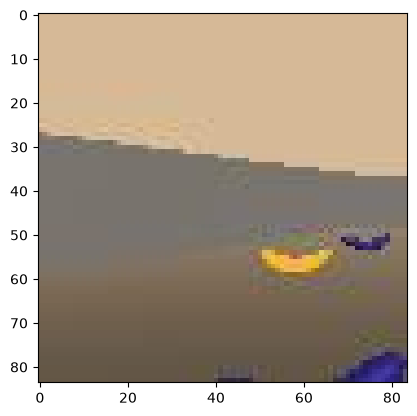

States have shape: (1, 84, 84, 3)


In [4]:
# reset the environment
env_info = env.reset(train_mode=True)[brain_name]

# number of agents in the environment
print('Number of agents:', len(env_info.agents))

# number of actions
action_size = brain.vector_action_space_size
print('Number of actions:', action_size)

# examine the state space 
state = env_info.visual_observations[0]
print('States look like:')
plt.imshow(np.squeeze(state))
plt.show()
state_size = state.shape
print('States have shape:', state.shape)

### 3. Take Random Actions in the Environment

In the next code cell, you will learn how to use the Python API to control the agent and receive feedback from the environment.

Once this cell is executed, you will watch the agent's performance, if it selects an action (uniformly) at random with each time step.  A window should pop up that allows you to observe the agent, as it moves through the environment.  

Of course, you'll have to change the code so that the agent is able to use its experience to gradually choose better actions when interacting with the environment!

In [3]:
env_info = env.reset(train_mode=False)[brain_name] # reset the environment
state = env_info.visual_observations[0]            # get the current state
score = 0                                          # initialize the score
while True:
    action = np.random.randint(action_size)        # select an action
    env_info = env.step(action)[brain_name]        # send the action to the environment
    next_state = env_info.visual_observations[0]   # get the next state
    reward = env_info.rewards[0]                   # get the reward
    done = env_info.local_done[0]                  # see if episode has finished
    score += reward                                # update the score
    state = next_state                             # roll over the state to next time step
    if done:                                       # exit loop if episode finished
        break
    
print("Score: {}".format(score))

NameError: name 'env' is not defined

When finished, you can close the environment.

In [ ]:
env.close()

### 4. It's Your Turn!

Now it's your turn to train your own agent to solve the environment!  When training the environment, set `train_mode=True`, so that the line for resetting the environment looks like the following:
```python
env_info = env.reset(train_mode=True)[brain_name]
```

In [5]:
agent = Agent(state_size=(4, 84, 84), action_size=action_size, seed=0, 
            qnetwork_class=DQNNatureNetwork,
            replay_start_size=10000,
            use_prioritized=False,
            use_double_dqn=False,
            use_noisy_nets=False,
            use_dueling=False,
            n_steps=1)

In [ ]:
def preprocess_frame(frame):
    frame = np.squeeze(frame)  # (1,84,84,3) -> (84,84,3)
    if frame.ndim != 3 or frame.shape[-1] != 3:
        raise ValueError(f"Expected RGB frame shape (84, 84, 3), got {frame.shape}")

    grayscale = np.dot(frame[..., :3], [0.299, 0.587, 0.114]).astype(np.float32)
    # normalize image only when pulled from buffer objects, not when pulled from the environment; minimizes memory consumption considering larger replay buffers
    #if grayscale.max() > 1.0:
    #    grayscale /= 255.0  # keep pixels in [0, 1]
    return grayscale

def stack_frames(stacked_frames, frame, is_new_episode):
    processed_frame = preprocess_frame(frame)

    if is_new_episode:
        # Start episode with 4 identical frames (common DQN practice).
        stacked_frames = deque([processed_frame] * 4, maxlen=4)
    else:
        stacked_frames.append(processed_frame)

    stacked_state = np.stack(stacked_frames, axis=0).astype(np.float32)
    if stacked_state.shape != (4, 84, 84):
        raise ValueError(f"Expected stacked state shape (4, 84, 84), got {stacked_state.shape}")
    return stacked_state, stacked_frames

def save_checkpoint(path, agent):
    checkpoint = {
        'model_state_dict': agent.qnetwork_local.state_dict(),
        'agent_config': {
            'qnetwork_class': agent.qnetwork_local.__class__.__name__,
            'use_prioritized': getattr(agent, 'use_prioritized', False),
            'use_double_dqn': getattr(agent, 'use_double_dqn', False),
            'use_noisy_nets': getattr(agent, 'use_noisy_nets', False),
            'use_dueling': getattr(agent, 'use_dueling', False),
            'n_steps': getattr(agent, 'n_steps', 1),
        }
    }
    torch.save(checkpoint, path)


In [ ]:
def dqn(n_episodes=2000, max_t=1000, eps_start=1.0, eps_end=0.01, eps_decay=0.995):
    """Deep Q-Learning.
    
    Params
    ======
        n_episodes (int): maximum number of training episodes
        max_t (int): maximum number of timesteps per episode
        eps_start (float): starting value of epsilon, for epsilon-greedy action selection
        eps_end (float): minimum value of epsilon
        eps_decay (float): multiplicative factor (per episode) for decreasing epsilon
    """
    scores = []                        # list containing scores from each episode
    scores_window = deque(maxlen=100)  # last 100 scores
    eps = eps_start                    # initialize epsilon
    best_average_score = float('-inf') # best 100-episode average seen so far
    for i_episode in range(1, n_episodes+1):
        env_info = env.reset(train_mode=True)[brain_name]

        stacked_frames = deque(maxlen=4)
        state, stacked_frames = stack_frames(stacked_frames, env_info.visual_observations[0], True)

        score = 0
        
        for t in range(max_t):
            action = agent.act(state, eps)

            env_info = env.step(action)[brain_name]
            next_state, stacked_frames = stack_frames(stacked_frames, env_info.visual_observations[0], False)

            reward = env_info.rewards[0]
            done = env_info.local_done[0]

            agent.step(state, action, reward, next_state, done)
            state = next_state
            score += reward
            if done:
                break 

        scores_window.append(score)       # save most recent score
        scores.append(score)              # save most recent score
        eps = max(eps_end, eps_decay*eps) # decrease epsilon
        current_average_score = np.mean(scores_window)
        print('\rEpisode {}\tAverage Score: {:.2f}'.format(i_episode, current_average_score), end="")
        if i_episode % 50 == 0:
            print('\rEpisode {}\tAverage Score: {:.2f}'.format(i_episode, current_average_score))
            if current_average_score > best_average_score:
                best_average_score = current_average_score
                save_checkpoint('rainbow_cnn.pth', agent)
                print('New best model saved with Average Score: {:.2f}'.format(best_average_score))
        if current_average_score >= 13.0:
            print('\nEnvironment solved in {:d} episodes!\tAverage Score: {:.2f}'.format(i_episode-100, current_average_score))
            save_checkpoint('rainbow_cnn.pth', agent)
            break

    return scores

scores = dqn()

# plot the scores
fig = plt.figure()
ax = fig.add_subplot(111)
plt.plot(np.arange(len(scores)), scores)
plt.ylabel('Score')
plt.xlabel('Episode #')
plt.show()

Episode 50	Average Score: 0.022
New best model saved with Average Score: 0.02
Episode 100	Average Score: -0.03
Episode 150	Average Score: -0.07
Episode 200	Average Score: 0.011
Episode 250	Average Score: 0.14
New best model saved with Average Score: 0.14
Episode 300	Average Score: 0.23
New best model saved with Average Score: 0.23
Episode 350	Average Score: 0.121
Episode 400	Average Score: 0.162
Episode 450	Average Score: 0.28
New best model saved with Average Score: 0.28
Episode 500	Average Score: 0.35
New best model saved with Average Score: 0.35
Episode 550	Average Score: 0.82
New best model saved with Average Score: 0.82
Episode 600	Average Score: 1.08
New best model saved with Average Score: 1.08
Episode 650	Average Score: 1.07
Episode 700	Average Score: 1.30
New best model saved with Average Score: 1.30
Episode 750	Average Score: 1.56
New best model saved with Average Score: 1.56
Episode 800	Average Score: 1.75
New best model saved with Average Score: 1.75
Episode 850	Average Sco

KeyboardInterrupt: 

: 

In [9]:
# Load checkpoint safely (supports old plain state_dict and new metadata checkpoint)
import os

ckpt_path = 'rainbow_cnn.pth'
if not os.path.exists(ckpt_path):
    raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}. Train first or check path.")

ckpt = torch.load(ckpt_path, map_location=torch.device('cpu'))

if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
    state_dict = ckpt['model_state_dict']
    saved_cfg = ckpt.get('agent_config', {})
else:
    # Backward compatibility: older notebook saved raw state_dict directly
    state_dict = ckpt
    saved_cfg = {}

try:
    agent.qnetwork_local.load_state_dict(state_dict, strict=True)
    agent.qnetwork_target.load_state_dict(state_dict, strict=True)
    print('Checkpoint loaded successfully into local and target networks.')
    if saved_cfg:
        print('Saved checkpoint config:', saved_cfg)
except RuntimeError as e:
    print('Failed to load checkpoint with current agent architecture.')
    if saved_cfg:
        print('Checkpoint was created with config:', saved_cfg)
    print('Current network class:', agent.qnetwork_local.__class__.__name__)
    print('Error details:\n', e)
    print('Hint: Recreate agent with the same architecture flags used during training, then load again.')

Checkpoint loaded successfully into local and target networks.
Saved checkpoint config: {'qnetwork_class': 'DQNNatureNetwork', 'use_prioritized': False, 'use_double_dqn': False, 'use_noisy_nets': False, 'use_dueling': False, 'n_steps': 1}


In [13]:
# Watch the trained agent play one episode (with the same preprocessing as training)
env_info = env.reset(train_mode=False)[brain_name]  # reset the environment

stacked_frames = deque(maxlen=4)
state, stacked_frames = stack_frames(stacked_frames, env_info.visual_observations[0], True)
score = 0  # initialize the score

while True:
    action = agent.act(state)  # greedy action (NoisyNet is deterministic in eval mode)
    env_info = env.step(int(action))[brain_name]
    next_state, stacked_frames = stack_frames(stacked_frames, env_info.visual_observations[0], False)
    reward = env_info.rewards[0]
    done = env_info.local_done[0]

    score += reward
    state = next_state
    if done:
        break

print("Score: {}".format(score))

env.close()

UnityEnvironmentException: No Unity environment is loaded.